<a href="https://colab.research.google.com/github/littlePanda2/ml-assignments/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 2: Hierarchical Clustering and linkage measures

**Course:** WBCS032-05 Introduction to Machine Learning  
**Student Names:** Sophie Schoerner, Marc
**Student Numbers:** s4136594

---

## Assignment Overview

In this assignment, you will implement the agglomerative hierarchical clustering algorithm as introduced and discussed in class, using Euclidean distance. Consider

(a) different linkage measures: *single*, *average*, *complete*, and *ward* linkage functions.

(b) three different choices for the number of clusters K = 2, 3, 4.

You will work with the data `data_clustering.csv`, which contains 200
two-dimensional feature vectors. There are no labels associated with the data points.

## 1. Introduction (1 point)

Describe the goal of this assignment.

**Your answer here:**

Goal of the assignment is to implement agglomerative hierarchical clustering using Euclidean distance and compare linkage measures (single, average, complete, and ward). Agglomerative hierarchical clustering is a bottom-up approach that starts with each data point as its own cluster and then repeatedly merges the two closest clusters until the desired number of clusters is reached. The linkage measures differ in how the distance between two clusters is defined (e.g. based on closest points, farthest points, av. distance, or the increase in within-cluster variance). The clustering results are evaluated for different numbers of clusters (K = 2, 3, 4) using quantitative metrics such as the silhouette score, within-cluster sum of squares (WSS), and between-cluster sum of squares (BSS), as well as qualitative visualizations like dendrograms and cluster plots. The objective is to determine which linkage method and number of clusters produce the best clustering structure!

## 2. Methods (3 points)

### 2.1 Explain agglomerative hierarchical clustering algorithm (0.5 points)

Explain the algorithm in a general manner, including different linkage measures.

**Your answer here:**

Agglomerative hierarchical clustering is a bottom-up clustering algorithm. It starts with each data point as its own cluster and repeatedly merges the two closest clusters until only one cluster remains or a desired number of clusters is reached. The result can be visualized as a dendrogram, which shows how clusters are merged step by step.

The difference between linkage measures lies in how the distance between two clusters is defined. In single linkage, the distance between the closest points of two clusters is used. In complete linkage, the distance between the farthest points is considered. Average linkage computes the average distance between all pairs of points from the two clusters. Ward linkage merges clusters in a way that minimizes the increase in within-cluster variance (often producing compact and well-separated clusters).

### 2.2 Implementation (2.5 points)

You are allowed to implement the algorithm using built-in functions from *sklearn* for linkage measures and the dendrogram. You need to implement the evaluation metrics (incl. silhouette score, within-cluster sum of squares and between-cluster sum of squares) **yourself**. Both the code quality and correctness will be graded.

*__Note:__* **Do not change the cell labels! Themis will use them to automatically grade your submission.**

In [ ]:
# Load required libraries
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Data configuration
data_file_path = 'data_clustering.csv'
df = pd.read_csv(data_file_path, header=None)
data = np.array(df)

# Linkage measures
linkage_measures = ["single", "average", "complete", "ward"]

# The number of clusters
clusters_K = [2, 3, 4]

Write code in the cell below to visualize the input data.

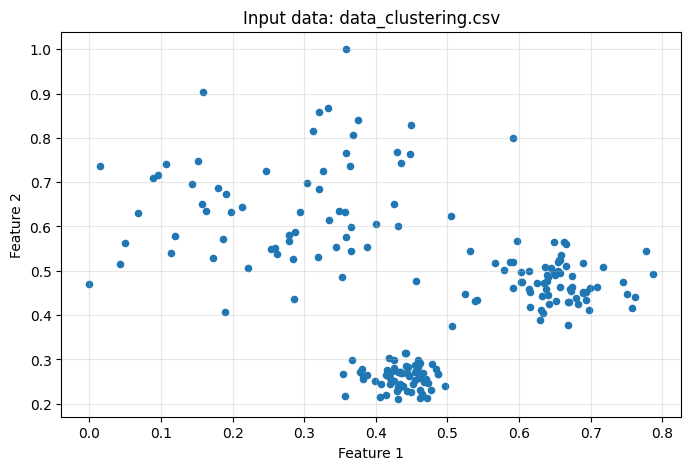

In [ ]:
# TODO: Visualize the data points.
plt.figure(figsize=(8, 5))
plt.scatter(data[:, 0], data[:, 1], s=20)
plt.title("Input data: data_clustering.csv")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

In the cell below, write code to perform hierarchical clustering using sklearn. Use the different linkage measures and number of clusters specified above. Store the cluster labels for each combination of linkage measure and number of clusters in a dictionary.

In [ ]:
# TODO: Perform hierarchical clustering and store labels for each combination of K and linkage measure

all_labels = {}

for linkage_measure in linkage_measures:
  for k in clusters_K:
    model = AgglomerativeClustering(n_clusters=k, linkage=linkage_measure)
    labels = model.fit_predict(input_data := data)
    all_labels[(linkage_measure, k)] = labels

all_labels

{('single',
  2): array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0]),
 ('single',
  3): array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In the cells below, complete the implementation of the evaluation metrics (silhouette score, within-cluster sum of squares and between-cluster sum of squares).

In [ ]:
def silhouette_score_defined(input_data, labels):
    """
    Compute the self-defined Silhouette Score.

    Args:
        input_data (ndarray): Data points.
        labels (ndarray): Labels of the data points.

    Returns:
        float: The mean silhouette score for all points.
    """

    # TODO: Implement the silhouette score calculation.

    unique_labels = np.unique(labels)
    n = len(input_data)
    silhouette_vals = []

    for i in range(n):
      same_cluster = input_data[labels == labels[i]]
      other_clusters = [input_data[labels == l] for l in unique_labels if l != labels[i]]

      # a = average distance to same cluster
      if len(same_cluster) > 1:
          a = np.mean(np.linalg.norm(same_cluster - input_data[i], axis=1))
      else:
          a = 0

      # b = smallest avg distance to other clusters
      b = np.inf
      for cluster in other_clusters:
          dist = np.mean(np.linalg.norm(cluster - input_data[i], axis=1))
          b = min(b, dist)

      s = (b - a) / max(a, b) if max(a, b) != 0 else 0
      silhouette_vals.append(s)

    return np.mean(silhouette_vals)

# silhouette score for all (linkage, K) combos
for linkage_measure in linkage_measures:
    for k in clusters_K:
        labels = all_labels[(linkage_measure, k)]
        score = silhouette_score_defined(data, labels)
        print(f"linkage={linkage_measure:8s}  K={k}  silhouette={score:.4f}")

linkage=single    K=2  silhouette=0.3848
linkage=single    K=3  silhouette=0.1937
linkage=single    K=4  silhouette=0.2035
linkage=average   K=2  silhouette=0.5460
linkage=average   K=3  silhouette=0.6565
linkage=average   K=4  silhouette=0.6355
linkage=complete  K=2  silhouette=0.4702
linkage=complete  K=3  silhouette=0.4279
linkage=complete  K=4  silhouette=0.4991
linkage=ward      K=2  silhouette=0.5459
linkage=ward      K=3  silhouette=0.6562
linkage=ward      K=4  silhouette=0.6337


In [ ]:
def compute_wss_bss(input_data, labels):
    """
    Compute Within-Cluster Sum of Squares (WSS) and Between-Cluster Sum of Squares (BSS).

    Args:
        input_data (ndarray): Data points.
        labels (ndarray): Labels of the data points.

    Returns:
        tuple: (WSS, BSS)
    """

    # TODO: Implement the WSS and BSS calculation.

    unique_labels = np.unique(labels)

    # overall mean of all points
    overall_mean = np.mean(input_data, axis=0)

    wss = 0.0
    bss = 0.0

    for lbl in unique_labels:
      cluster_points = input_data[labels == lbl]
      cluster_mean = np.mean(cluster_points, axis=0)

      # WSS: sum of squared distances to cluster mean
      wss += np.sum((cluster_points - cluster_mean) ** 2)

      # BSS: cluster size * squared distance of cluster mean to overall mean
      n_k = cluster_points.shape[0]
      bss += n_k * np.sum((cluster_mean - overall_mean) ** 2)

    return wss, bss

# print result
wss, bss = compute_wss_bss(data, labels)
print("WSS:", wss)
print("BSS:", bss)

WSS: 1.6936427369225622
BSS: 10.420050476166043


## 3. Experimental Results (4 points)

*__Note:__* This section **is graded** by Themis.

### 3.1 Qualitative result

1. Implement `plot_dendrogram(input_data, linkage_measure, cutoff)` - Plot a dendrogram for the given linkage measure and indicate the corresponding cut-off thresholds using dashed horizontal lines.

2. Implement `plot_clustering_results(input_data, k, linkage_measure)` - Plot the clustering results for a given number of clusters and linkage measure.


In [ ]:
def plot_dendrogram(input_data, linkage_measure, cutoff):
    """
    Plot a single dendrogram, based on the given parameters.

    Args:
        input_data (ndarray): Data points.
        linkage_measure (str): The linkage measure (e.g. 'single').
        cutoff (list): List of cut-off thresholds.
    """

    # TODO: Implement the dendrogram plotting.

    pass

In [ ]:
def plot_clustering_results(input_data, k, linkage_measure):
    """
    Plot clustering results for given k and linkage measure.

    Args:
        input_data (ndarray): Data points.
        k (int): Number of clusters.
        linkage_measure (str): Linkage measure used for clustering.
    """

    # TODO: Implement the clustering results plotting.

    pass

### 3.2 Quantitative result

1. Implement `compute_silhouette_scores(input_data, k, linkage_measure)` - Compute and return the silhouette score for the given clustering configuration.

2. Implement `compute_wss_bss_scores(input_data, k, linkage_measure)` - Compute and return the within-cluster sum of squares (WSS) and between-cluster sum of squares (BSS) for the given clustering configuration.

In [ ]:
def compute_silhouette_scores(input_data, k, linkage_measure):
    """
    Compute silhouette scores for different clustering results.

    Args:
        input_data (ndarray): Data points.
        k (int): Number of clusters.
        linkage_measure (str): Linkage measure used for clustering.

    Returns:
        float: Silhouette score for the given clustering configuration.
    """

    # TODO: Implement the silhouette score calculation for the given clustering configuration.

    pass

In [ ]:
def compute_wss_bss_scores(input_data, k, linkage_measure):
    """
    Compute WSS and BSS scores for different clustering results.

    Args:
        input_data (ndarray): Data points.
        k (int): Number of clusters.
        linkage_measure (str): Linkage measure used for clustering.

    Returns:
        tuple: WSS and BSS scores for the given clustering configuration.
    """

    # TODO: Implement the WSS and BSS score calculation for the given clustering configuration.

    pass

## 4. Discussion (2 points)

Discuss your observations on both the qualitative and quantitative results, and conclusions for the best choice of linkage measures and the number of clusters.

**Your answer here:**

## Contribution

State your individual contribution.

**Your answer here:**